# Setup Environment

In [1]:
# Import libraries

# Standard libraries
from pathlib import Path
import json

# Data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Models and evaluation libraries
import sklearn 
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# Gradient Boosting Libraries
from xgboost import XGBClassifier
from catboost import CatBoostClassifier 

# Tuning and optimization libraries
import optuna
import optuna.visualization as vis
from scipy.optimize import minimize
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

# Saving and loading models
import joblib

print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

NumPy version: 2.4.5
pandas version: 3.0.3
matplotlib version: 3.11.0
seaborn version: 0.13.2
Scikit-Learn version: 1.9.0


In [2]:
# Create image and model directories if they don't exist

eda_plots_dir             = Path("plots/EDA")
tuning_plots_dir          = Path("plots/Tuning")
evaluation_plots_dir      = Path("plots/Evaluation")
features_plots_dir        = Path("plots/Features")
models_dir                = Path("models")

eda_plots_dir.mkdir(parents=True, exist_ok=True)
tuning_plots_dir.mkdir(parents=True, exist_ok=True)
evaluation_plots_dir.mkdir(parents=True, exist_ok=True)
features_plots_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# UnicodeDecodeError: 'cp950' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

# Fix for sklearn display issue in Jupyter Notebook
import sklearn.utils._repr_html.estimator as est_module

def fix_sklearn_unicode():
    original_open = open
    def patched_open(file, mode='r', *args, **kwargs):
        if mode.startswith('r') and isinstance(file, str) and file.endswith("estimator.js"):
            kwargs['encoding'] = 'utf-8'
        return original_open(file, mode, *args, **kwargs)
    
    est_module.open = patched_open

fix_sklearn_unicode()
print("Sklearn display issue patched for Jupyter Notebook.")

Sklearn display issue patched for Jupyter Notebook.


# Data Collection and Preprocessing

In [4]:
# Load the dataset

# make the data directory if it doesn't exist
if not Path('data').exists():
    Path('data').mkdir()

# download the dataset if it doesn't exist, else load it from the local file
if not Path('data/credit_scoring.csv').is_file():
    data_url = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv'
    df = pd.read_csv(data_url, encoding='utf-8')
    df.to_csv('data/credit_scoring.csv', index=False)
else:
    df = pd.read_csv('data/credit_scoring.csv', encoding='utf-8')
 
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4455 entries, 0 to 4454
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Status     4455 non-null   int64
 1   Seniority  4455 non-null   int64
 2   Home       4455 non-null   int64
 3   Time       4455 non-null   int64
 4   Age        4455 non-null   int64
 5   Marital    4455 non-null   int64
 6   Records    4455 non-null   int64
 7   Job        4455 non-null   int64
 8   Expenses   4455 non-null   int64
 9   Income     4455 non-null   int64
 10  Assets     4455 non-null   int64
 11  Debt       4455 non-null   int64
 12  Amount     4455 non-null   int64
 13  Price      4455 non-null   int64
dtypes: int64(14)
memory usage: 487.4 KB


,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [5]:
# Data Cleaning: Convert column names to lowercase, Replace placeholder values

# Convert all column names to lowercase
df.columns = df.columns.str.lower()

# Replace placeholder value 99999999 with NaN
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)


In [6]:
# Data Cleaning: Convert categorical variables to their corresponding string values using mapping dictionaries
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

df.home    = df.home.map(home_values)
df.marital = df.marital.map(marital_values)
df.records = df.records.map(records_values)
df.job     = df.job.map(job_values)
df.status  = df.status.map(status_values)
df = df[df.status != 'unk'].reset_index(drop=True)  # Remove rows with unknown status values and reset the index

# Check the data types of the columns and display summary statistics for numerical columns
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4454.0,4454.0,4454.0,4454.0,4420.0,4407.0,4436.0,4454.0,4454.0
mean,8.0,46.0,37.0,56.0,131.0,5404.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11574.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1117.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


# Exploratory Data Analysis (EDA)

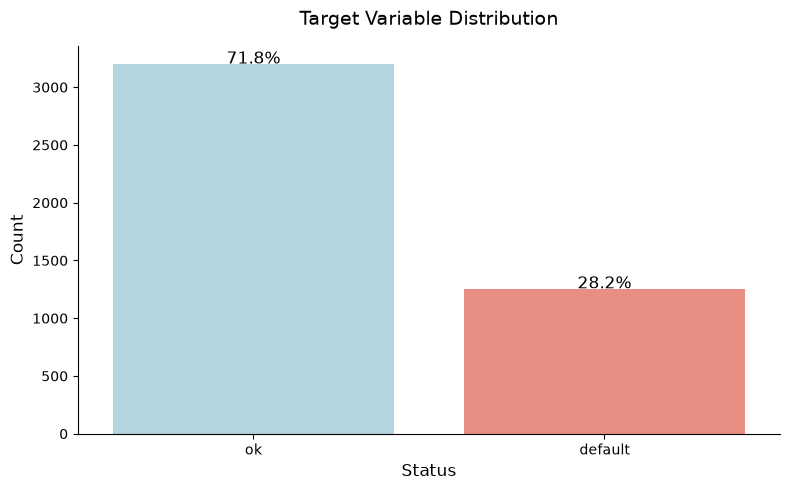

In [7]:
# Plot the vertical bar chart of the target variable from df

# Calculate the percentage of each status value and create a new DataFrame for plotting
df_status = df['status'].value_counts(normalize=True).mul(100).rename('percent').reset_index()
df_status.columns = ['Status', 'percent']
df_status['count'] = df['status'].value_counts().values

# Plot the vertical bar chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Status', y='count', data=df_status, palette=['lightblue', 'salmon'], hue='Status', legend=False)

# Annotate the bars with the percentage values
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 5, 
            f'{df_status["percent"][i]:.1f}%', ha="center", fontsize=12)

plt.title('Target Variable Distribution', fontsize=14, pad=15)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Status', fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig(eda_plots_dir/ '01_target_variable_distribution.png', dpi=300)
plt.show()

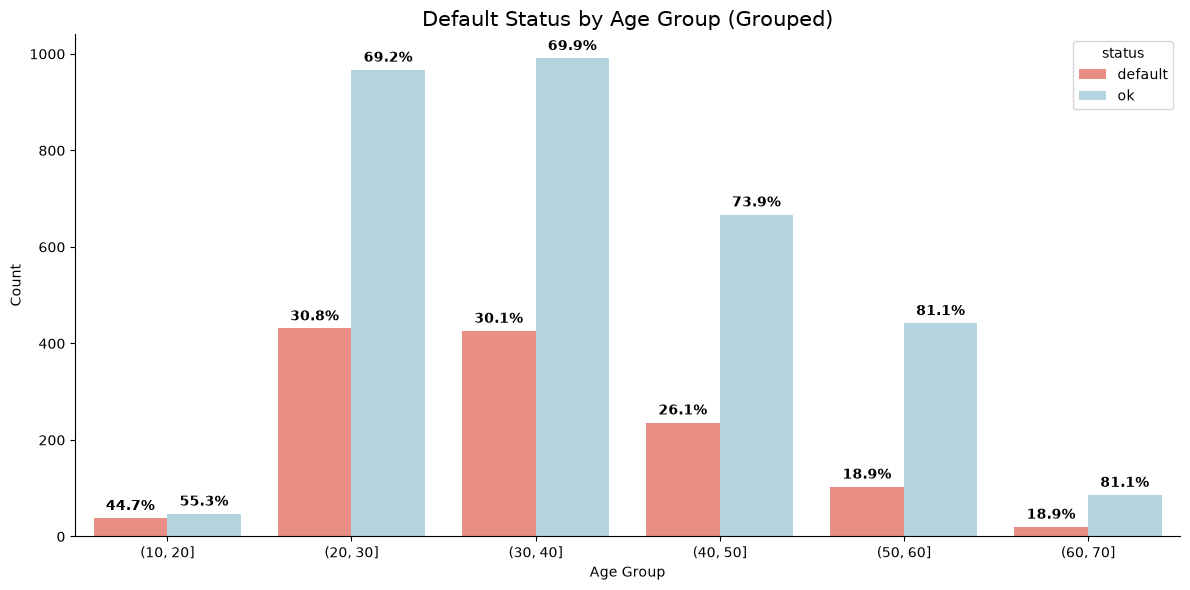

In [8]:
# Age Distribution Analysis: Create age groups and plot the distribution of default status by age group

# 1. Use a copy of the dataframe for analysis to protect original data
df_analysis = df.copy()

# 2. Create age groups
bins = range(10, 80, 10)
df_analysis['age_group'] = pd.cut(df_analysis['age'], bins=bins)

# 3. Use crosstab to get counts and normalize for percentages
# normalize='index' calculates the percentage within each age group
ct = pd.crosstab(df_analysis['age_group'], df_analysis['status'])
ct_pct = pd.crosstab(df_analysis['age_group'], df_analysis['status'], normalize='index') * 100

# 4. Melt the dataframe for Seaborn plotting (converts wide to long format)
df_plot = ct.reset_index().melt(id_vars='age_group', var_name='status', value_name='count')

# 5. Create the Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='age_group', 
    y='count', 
    hue='status', 
    data=df_plot, 
    palette={'default': 'salmon', 'ok': 'lightblue'}
)

# 6. Add percentage labels on top of each bar
# We iterate through the bars and fetch the percentage from our normalized crosstab
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        # Get age group and status from the bar position and order
        age_idx = i % len(ct)
        status_col = 'default' if i < len(ct) else 'ok'
        pct = ct_pct.loc[ct_pct.index[age_idx], status_col]
        
        ax.text(
            p.get_x() + p.get_width() / 2, 
            height + 10, 
            f'{pct:.1f}%', 
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.title('Default Status by Age Group (Grouped)', fontsize=15)
plt.ylabel('Count')
plt.xlabel('Age Group')
sns.despine()
plt.tight_layout()
plt.savefig(eda_plots_dir/ '02_default_status_by_age_group.png', dpi=300)
plt.show()

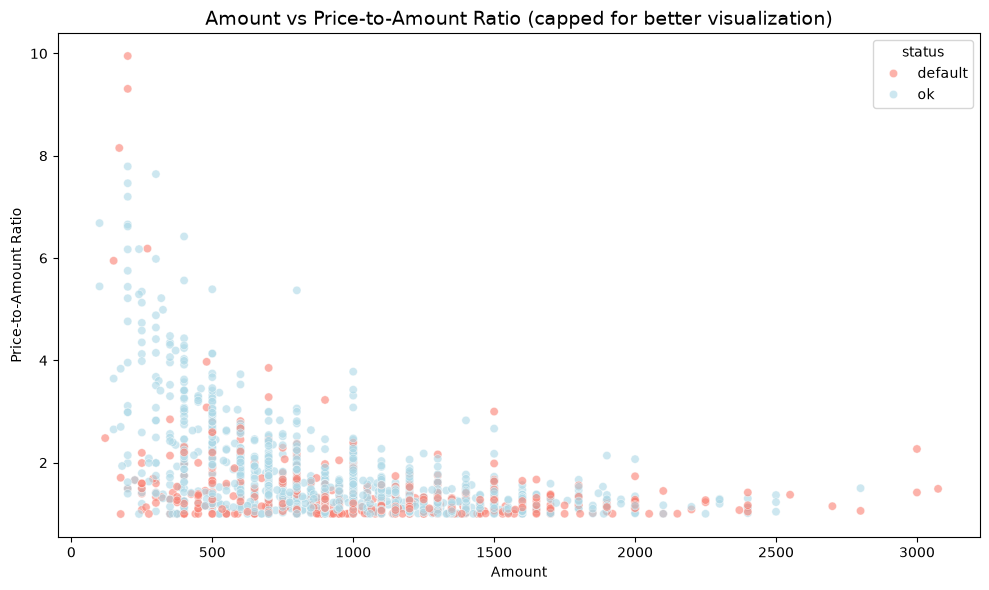

In [9]:
# Multivariate Analysis: Scatter plot of amount vs price colored by status

# Create a new DataFrame for analysis to avoid modifying the original df
df_analysis = df.copy()
df_analysis['diff'] = df_analysis['price'] - df_analysis['amount']
df_analysis['ratio'] = df_analysis['price'] / (df_analysis['amount'] + 1)

# filter out extreme values for better visualization
df_analysis = df_analysis[(df_analysis['amount'] < 3500) & (df_analysis['diff'].abs() < 5000) & (df_analysis['ratio'] < 10)]
max_samples = 2000
df_analysis_sample = df_analysis.sample(n=max_samples, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_analysis_sample, x='amount', y='ratio', hue='status', palette= {'ok': 'lightblue', 'default': 'salmon'}, alpha=0.6)
plt.title('Amount vs Price-to-Amount Ratio (capped for better visualization)', fontsize=14)
plt.xlabel('Amount')
plt.ylabel('Price-to-Amount Ratio')
plt.tight_layout()
plt.savefig(eda_plots_dir/ '03_amount_vs_price_ratio.png', dpi=300)
plt.show()

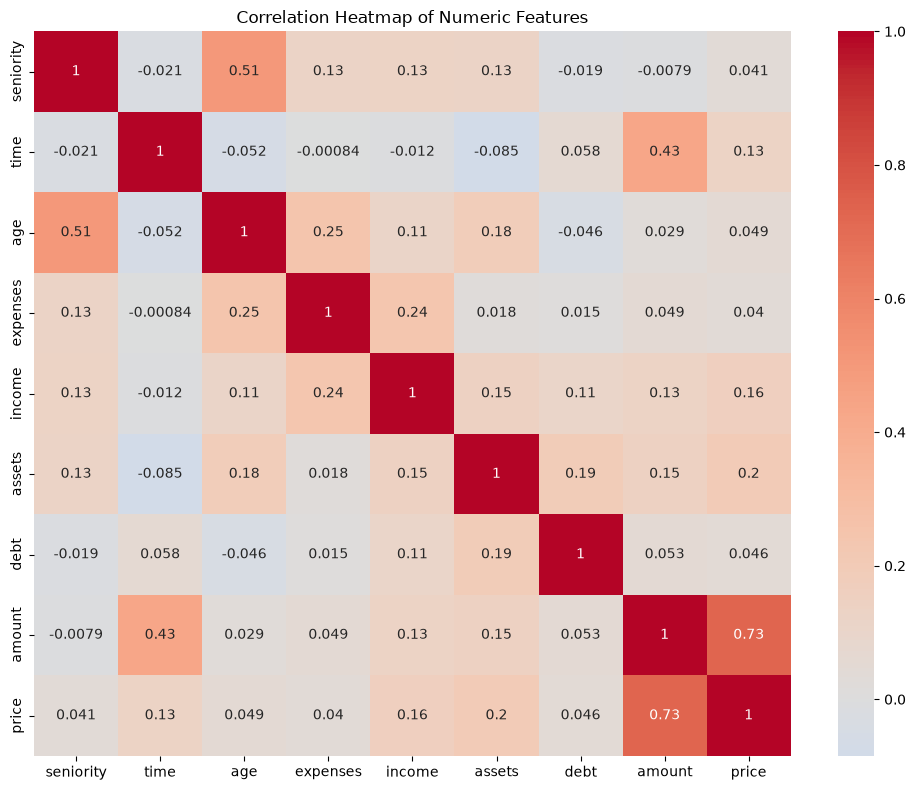

In [10]:
# Correlation Heatmap
df_analysis = df.copy()
# keep only numeric columns for correlation analysis
df_analysis = df_analysis.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(df_analysis.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig(eda_plots_dir/ '04_correlation_heatmap.png', dpi=300)
plt.show()

# Data Splitting & Feature Engineering

In [11]:
# Data splitting

# Split the dataset into training, validation, and test sets with a 60-20-20 split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

# Reset the index of the dataframes to ensure that the indices are sequential and start from 0
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

# Change the target variable to a binary indicator
# If the status is 'default', we set it to 1, otherwise we set it to 0, then convert it to a numpy array
y_train = (df_train.status == 'default').astype('int').values
y_val   = (df_val.status == 'default').astype('int').values
y_test  = (df_test.status == 'default').astype('int').values

# Remove the target variable 'status'
del df_train['status']
del df_val['status']
del df_test['status']

df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,10,owner,36,36,married,no,freelance,75,0.0,10000.0,0.0,1000,1400
1,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
2,1,parents,48,40,married,no,fixed,75,121.0,0.0,0.0,1320,1600
3,1,parents,48,23,single,no,partime,35,72.0,0.0,0.0,1078,1079
4,5,owner,36,46,married,no,freelance,60,100.0,4000.0,0.0,1100,1897
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2667,18,private,36,45,married,no,fixed,45,220.0,20000.0,0.0,800,1600
2668,7,private,60,29,married,no,fixed,60,51.0,3500.0,500.0,1000,1290
2669,1,parents,24,19,single,no,fixed,35,28.0,0.0,0.0,400,600
2670,15,owner,48,43,married,no,freelance,60,100.0,18000.0,0.0,2500,2976


In [12]:
# Feature Engineering 

def feature_engineering(df):
    df = df.copy()
    
    # 1. Age Binning
    bins = [0, 20, 30, 40, 50, 60, 100]
    if 'age' in df.columns:
        df['age_group'] = pd.cut(df['age'], bins=bins).astype(str)
        df.drop(columns=['age'], inplace=True)
    
    # 2. Price and amount (differences and ratios)
    df['diff'] = df['price'] - df['amount']
    df['ratio'] = df['price'] / (df['amount'] + 1)
    
    # 3. Affordability metrics
    df['debt_income_ratio'] = df['debt'] / (df['income'] + 1)
    df['assets_amount_ratio'] = df['assets'] / (df['amount'] + 1)
    # Cap extreme values to reduce noise in tree models
    for col in ['debt_income_ratio', 'assets_amount_ratio']:
        upper_limit = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=upper_limit)
    
    return df

# Apply feature engineering to the training, validation, and test datasets
df_train_eng = feature_engineering(df_train)
df_val_eng   = feature_engineering(df_val)
df_test_eng  = feature_engineering(df_test)

# Convert the dataframes to dictionaries and then vectorize them using DictVectorizer
dv = DictVectorizer(sparse=True)

train_dicts = df_train_eng.fillna(0).to_dict(orient='records')
val_dicts   = df_val_eng.fillna(0).to_dict(orient='records')
test_dicts  = df_test_eng.fillna(0).to_dict(orient='records')

X_train = dv.fit_transform(train_dicts)
X_val   = dv.transform(val_dicts)
X_test  = dv.transform(test_dicts)


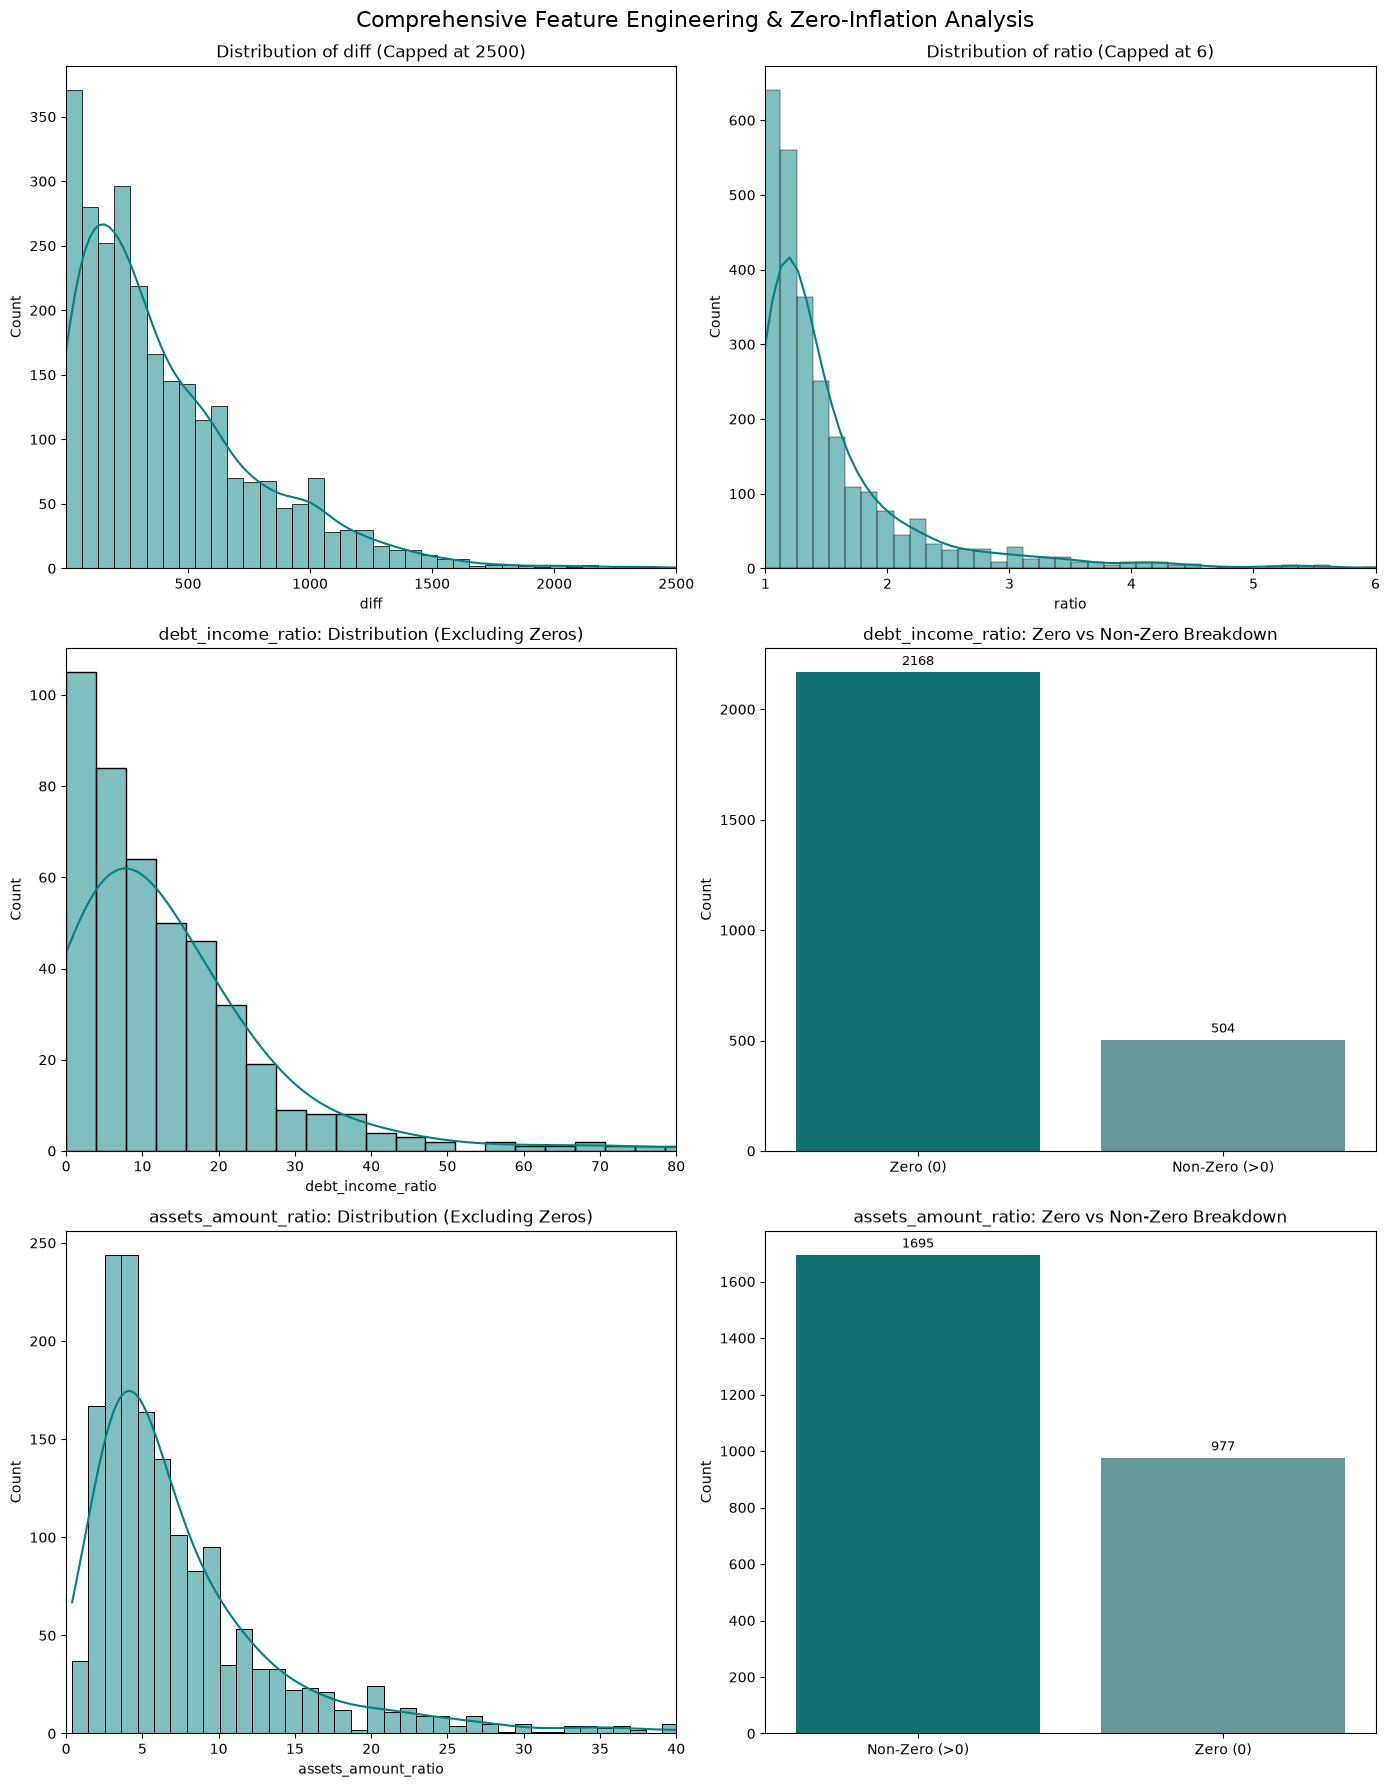

In [13]:
# Visualization of Engineered Features

# 3 rows and 2 columns of subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# --- Row 0: Diff & Ratio ---
sns.histplot(df_train_eng['diff'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribution of diff (Capped at 2500)', fontsize=12)
axes[0, 0].set_xlabel('diff')
axes[0, 0].set_xlim(1, 2500)

sns.histplot(df_train_eng['ratio'], kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Distribution of ratio (Capped at 6)', fontsize=12)
axes[0, 1].set_xlabel('ratio')
axes[0, 1].set_xlim(1, 6)

# --- Rows 1 & 2: Debt-Income Ratio & Assets-Amount Ratio (Handled via Loop) ---
ratio_configs = [
    {'feature': 'debt_income_ratio', 'row': 1, 'xlim': 80},
    {'feature': 'assets_amount_ratio', 'row': 2, 'xlim': 40}
]

for config in ratio_configs:
    feat = config['feature']
    r_idx = config['row']
    
    # Left：Zoomed distribution plot for non-zero values
    data_nz = df_train_eng[df_train_eng[feat] > 0][feat]
    sns.histplot(data_nz, kde=True, ax=axes[r_idx, 0], color='teal')
    axes[r_idx, 0].set_title(f'{feat}: Distribution (Excluding Zeros)', fontsize=12)
    axes[r_idx, 0].set_xlabel(feat)
    axes[r_idx, 0].set_xlim(0, config['xlim'])

    # Right：Zero vs Non-Zero Bar plot 
    # with hue and legend=False to prevent future warnings
    is_zero = (df_train_eng[feat] == 0)
    counts = is_zero.map({True: 'Zero (0)', False: 'Non-Zero (>0)'}).value_counts()
    
    sns.barplot(
        x=counts.index, y=counts.values, 
        hue=counts.index, palette=['teal', 'cadetblue'], 
        ax=axes[r_idx, 1], legend=False
    )
    axes[r_idx, 1].set_title(f'{feat}: Zero vs Non-Zero Breakdown', fontsize=12)
    axes[r_idx, 1].set_ylabel('Count')
    axes[r_idx, 1].set_xlabel('')
    
    # annotate the bars with counts
    for p in axes[r_idx, 1].patches:
        axes[r_idx, 1].annotate(
            f'{int(p.get_height())}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='bottom', fontsize=9, xytext=(0, 3), 
            textcoords='offset points'
        )

plt.suptitle('Comprehensive Feature Engineering & Zero-Inflation Analysis', fontsize=16, y=0.99)
plt.tight_layout()
plt.savefig(eda_plots_dir / '05_comprehensive_features_analysis.png', dpi=300)
plt.show()

# Models Benchmark

In [14]:
# Helper Function for ROC AUC score on both training and validation sets

def auc_train_val(
        model, 
        X_train = X_train, y_train = y_train, 
        X_val = X_val, y_val = y_val
    ):
    
    # Predict probabilities for the positive class (class 1)
    y_pred_train = model.predict_proba(X_train)[:, 1]
    y_pred_val = model.predict_proba(X_val)[:, 1]
    
    # Calculate ROC AUC scores
    auc_train = roc_auc_score(y_train, y_pred_train)
    auc_val = roc_auc_score(y_val, y_pred_val)

    print(f"Model: {model.__class__.__name__}")
    print(f"Training set AUC:   {auc_train:.4f}")
    print(f"Validation set AUC: {auc_val:.4f}")
    
    return auc_train, auc_val

## 1. Decision Trees

In [15]:
# Decision Tree Classifier

dt_baseline = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10)
dt_baseline.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [16]:
# Evaluate the model using ROC AUC score on both training and validation sets

dt_base_auc_train, dt_base_auc_val = auc_train_val(dt_baseline)

# A bit overfitting, but not too bad. 

Model: DecisionTreeClassifier
Training set AUC:   0.8476
Validation set AUC: 0.7636


## 2. Random Forest

In [17]:
# Random Forest Classifier

rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [18]:
# Evaluate the model using ROC AUC score on both training and validation sets

rf_base_auc_train, rf_base_auc_val = auc_train_val(rf_baseline)

# Extreme overfitting

Model: RandomForestClassifier
Training set AUC:   1.0000
Validation set AUC: 0.8195


## 3. XGBoost

In [19]:
# Model fitting using XGBoost

# Define the XGBoost model with specified hyperparameters
xgb_baseline = XGBClassifier(
    n_estimators=200,
    learning_rate=0.3,
    max_depth=6,
    objective='binary:logistic',
    eval_metric='auc',
    early_stopping_rounds=10, # Early Stopping -> Prevents overfitting
    random_state=1
)

xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [20]:
# Evaluate the model using ROC AUC score on both training and validation sets

xgb_base_auc_train, xgb_base_auc_val = auc_train_val(xgb_baseline)

# overfitting

Model: XGBClassifier
Training set AUC:   0.9705
Validation set AUC: 0.8219


## 4. CatBoost 

In [21]:
# CatBoost

# Prepare the categorical features for CatBoost
categorical_features = ['home', 'marital', 'records', 'job', 'age_group']

for cat in categorical_features:
    df_train_eng[cat] = df_train_eng[cat].astype(str)
    df_val_eng[cat] = df_val_eng[cat].astype(str)
    df_test_eng[cat] = df_test_eng[cat].astype(str)

# fit the CatBoost model with specified hyperparameters
cat_baseline = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    cat_features=categorical_features, 
    verbose=100,
    random_state=42
)

cat_baseline.fit(df_train_eng, y_train)



0:	learn: 0.6307635	total: 173ms	remaining: 1m 26s
100:	learn: 0.2964085	total: 3.4s	remaining: 13.4s
200:	learn: 0.2268137	total: 6.77s	remaining: 10.1s
300:	learn: 0.1762000	total: 10.1s	remaining: 6.67s
400:	learn: 0.1406678	total: 13.4s	remaining: 3.3s
499:	learn: 0.1131891	total: 16.8s	remaining: 0us


CatBoostClassifier(cat_features=['home', 'marital', 'records', 'job', 'age_group'], depth=6, iterations=500, learning_rate=0.1, random_state=42, verbose=100)

In [22]:
# Evaluate the model using ROC AUC score on both training and validation sets

cat_base_auc_train, cat_base_auc_val = auc_train_val(cat_baseline, X_train=df_train_eng, X_val=df_val_eng)

# Overfitting

Model: CatBoostClassifier
Training set AUC:   0.9954
Validation set AUC: 0.8399


## 5. Compare baseline model

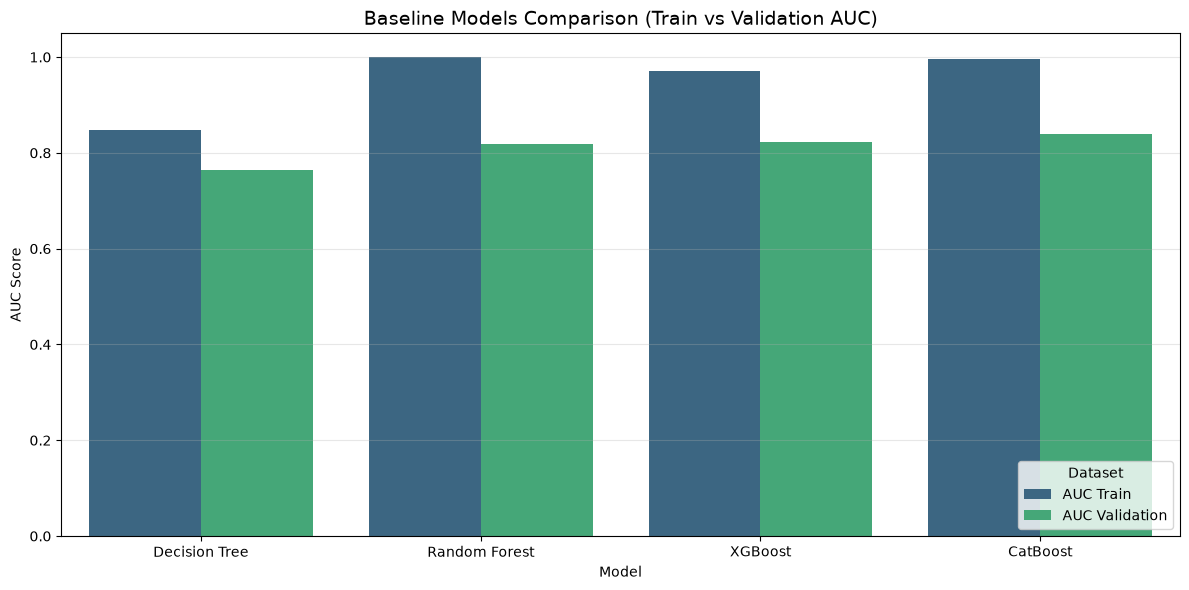

In [23]:
# Summary and visualization of Baseline Model Performance

# 1. Save to a dataframe for easy comparison and visualization
base_model_performance = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost', 'CatBoost'],
    'AUC Train': [dt_base_auc_train, rf_base_auc_train, xgb_base_auc_train, cat_base_auc_train],
    'AUC Validation': [dt_base_auc_val, rf_base_auc_val, xgb_base_auc_val, cat_base_auc_val]
})

base_model_performance.to_csv(models_dir / 'baseline_model_performance.csv', index=False)



# 2. Visualize the baseline model performance with a bar chart for visual comparison

# Melt the dataframe to long format for easier plotting with Seaborn
df_melted = base_model_performance.melt(
    id_vars='Model', 
    value_vars=['AUC Train', 'AUC Validation'], 
    var_name='Dataset', 
    value_name='AUC Score'
)

# Train and Validation Bar Plot
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x='Model', 
    y='AUC Score', 
    hue='Dataset',       # Use hue to differentiate between training and validation scores
    data=df_melted, 
    palette='viridis'
)

plt.title('Baseline Models Comparison (Train vs Validation AUC)', fontsize=14)
plt.ylim(0, 1.05)       
plt.grid(True, axis='y', alpha=0.3)
plt.legend(title='Dataset', loc='lower right')
plt.tight_layout()
plt.savefig(evaluation_plots_dir / '01_baseline_model_comparison.png', dpi=300)
plt.show()


# Hyperparameter Tuning

In [24]:
# Helper function for evaluating and storing model performance metrics

model_results = {}

def evaluate_and_store_model_performance(
        model, model_name, 
        X_train, y_train, 
        X_val, y_val,
        model_results = model_results
    ):

    # 1. Predict probabilities for the positive class (class 1)
    proba_train = model.predict_proba(X_train)
    proba_val = model.predict_proba(X_val)

    # 2. Extract the probabilities for the positive class (class 1)
    y_pred_train = proba_train[:, 1]
    y_pred_val = proba_val[:, 1]

    # 3. Calculate ROC AUC scores for both training and validation sets
    auc_train = roc_auc_score(y_train, y_pred_train)
    auc_val = roc_auc_score(y_val, y_pred_val)

    # 4. Store the results in the model_results dictionary
    model_results[model_name] = {
        'model': model,
        'train_pred': y_pred_train,
        'train_auc': auc_train,
        'val_pred': y_pred_val,
        'val_auc': auc_val
    }

    # 5. Print the results for quick reference
    print(f"--- Model: {model_name} ---")
    print(f"Training set AUC:   {auc_train:.3f}")
    print(f"Validation set AUC: {auc_val:.3f}\n")

    return

## 1. Tuning Decision Trees

In [25]:
# Tuning the depth of the decision tree

depths = [1, 2, 3, 4, 5, 6, 10, 15, 20, None]       # None means no limit on the depth of the tree

for depth in depths: 
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)
    
    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    
    print('%4s -> %.3f' % (depth, auc))

   1 -> 0.606
   2 -> 0.661
   3 -> 0.737
   4 -> 0.755
   5 -> 0.759
   6 -> 0.749
  10 -> 0.685
  15 -> 0.652
  20 -> 0.631
None -> 0.637


In [26]:
# Tuning the min_samples_leaf parameter of the Decision Tree Classifier
scores = []

for depth in [4, 5, 6]:     # Best depth is 5
    for s in [1, 5, 10, 15, 20, 500, 100, 200]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        
        scores.append((depth, s, auc))

print('depth  min_samples_leaf  auc')
for depth, s, auc in scores:
    print(f'{depth:5} {s:18} {auc:.3f}')

depth  min_samples_leaf  auc
    4                  1 0.755
    4                  5 0.757
    4                 10 0.750
    4                 15 0.754
    4                 20 0.750
    4                500 0.674
    4                100 0.752
    4                200 0.747
    5                  1 0.757
    5                  5 0.770
    5                 10 0.764
    5                 15 0.768
    5                 20 0.763
    5                500 0.674
    5                100 0.762
    5                200 0.763
    6                  1 0.750
    6                  5 0.772
    6                 10 0.771
    6                 15 0.768
    6                 20 0.770
    6                500 0.674
    6                100 0.780
    6                200 0.767


                    auc              
max_depth             4      5      6
min_samples_leaf                     
1                 0.755  0.757  0.750
5                 0.757  0.770  0.772
10                0.750  0.764  0.771
15                0.754  0.768  0.768
20                0.750  0.763  0.770
100               0.752  0.762  0.780
200               0.747  0.763  0.767
500               0.674  0.674  0.674


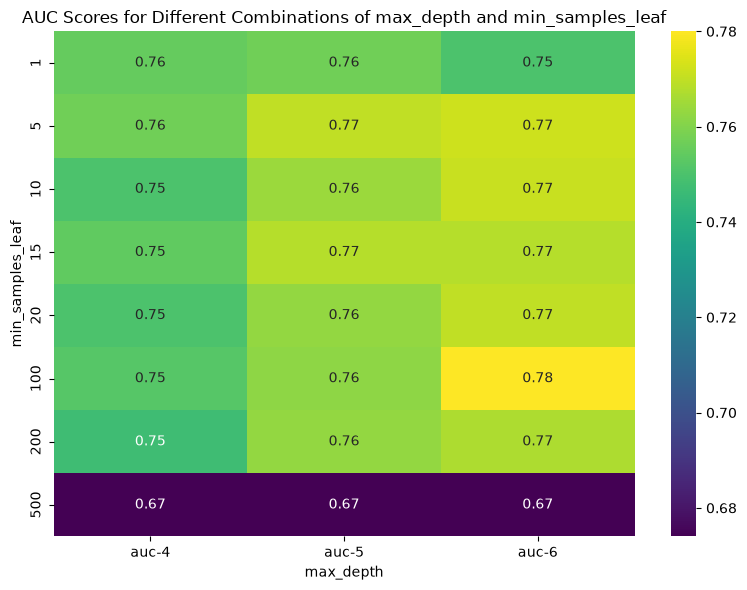

Best combination: max_depth=6.0, min_samples_leaf=100.0, AUC=0.780


In [27]:
# Visualize the results of the hyperparameter tuning using a heatmap

# Present the results in a pivot table format for better visualization
df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc'])
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
print(df_scores_pivot.round(3))

# plot the results using a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(df_scores_pivot.round(3), annot=True, cmap='viridis')
plt.title('AUC Scores for Different Combinations of max_depth and min_samples_leaf')
plt.xlabel('max_depth')
plt.ylabel('min_samples_leaf')
plt.tight_layout()
plt.savefig(tuning_plots_dir / "01_DT_tuning_heatmap.png", dpi=300)
plt.show()

# Find the best combination of max_depth and min_samples_leaf based on the highest AUC score
best_score = df_scores.loc[df_scores['auc'].idxmax()]
best_depth = best_score['max_depth']
best_samples_leaf = best_score['min_samples_leaf']
print(f"Best combination: max_depth={best_depth}, min_samples_leaf={best_samples_leaf}, AUC={best_score['auc']:.3f}")

In [28]:
# Evaluate the best model on the training and validation sets
dt_best = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt_best.fit(X_train, y_train)

evaluate_and_store_model_performance(dt_best, "Decision Tree", X_train, y_train, X_val, y_val)

--- Model: Decision Tree ---
Training set AUC:   0.874
Validation set AUC: 0.768



## 2. Tuning Random Forest

In [29]:
# Tunning with GridSearchCV

# Define the hyperparameter grid for Random Forest Classifier
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': np.arange(1, 10, 1)
}

# Define the Random Forest Classifier and GridSearchCV for hyperparameter tuning
rf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1,          # Use all available cores for parallel processing
    verbose=1           # Display progress messages during the search
)

# Fit the model and find the best hyperparameters
grid_search_rf.fit(X_train, y_train)
print(f"Best parameters: {grid_search_rf.best_params_}")
rf_best = grid_search_rf.best_estimator_


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': np.int64(5), 'n_estimators': 200}


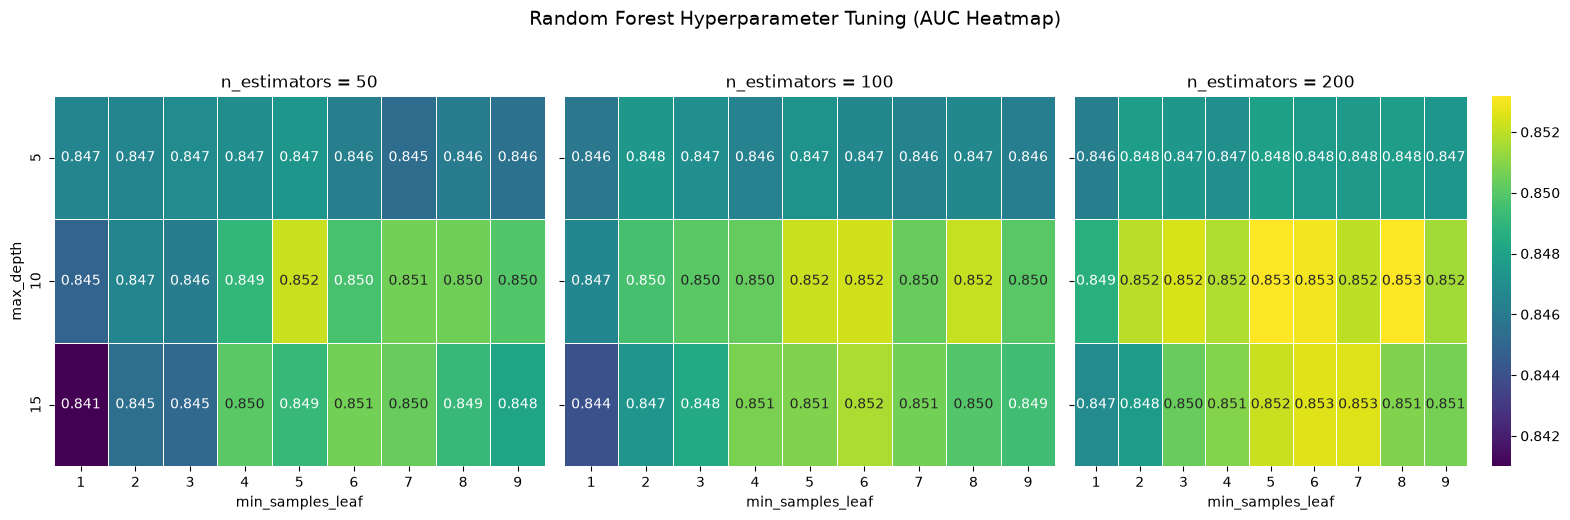

In [30]:
# AUC Heatmap Visualization for Random Forest Hyperparameter Tuning

# Transform the GridSearchCV results into a DataFrame
results_df = pd.DataFrame(grid_search_rf.cv_results_)

# Extract the required columns
# Column names correspond to: 'param_n_estimators', 'param_max_depth', 'param_min_samples_leaf', 'mean_test_score'
scores_df = results_df[[
    'param_n_estimators', 
    'param_max_depth', 
    'param_min_samples_leaf', 
    'mean_test_score'
]].copy()

# Convert the columns to appropriate numeric types
for col in scores_df.columns:
    scores_df[col] = pd.to_numeric(scores_df[col])

# Each unique value of n_estimators will have its own heatmap,
# with max_depth on the y-axis and min_samples_leaf on the x-axis. 
# The color intensity will represent the mean_test_score (AUC).
n_estimators_list = sorted(scores_df['param_n_estimators'].unique())
fig, axes = plt.subplots(1, len(n_estimators_list), figsize=(16, 5), sharey=True)

# Find the global min and max AUC ( to unify the color scale across all heatmaps)
vmin = scores_df['mean_test_score'].min()
vmax = scores_df['mean_test_score'].max()

for i, n_est in enumerate(n_estimators_list):
    ax = axes[i]

    # Filter the DataFrame for the current n_estimators value
    subset = scores_df[scores_df['param_n_estimators'] == n_est]
    
    pivot_table = subset.pivot(
        index='param_max_depth', 
        columns='param_min_samples_leaf', 
        values='mean_test_score'
    )
    
    # Heatmap
    sns.heatmap(
        pivot_table, 
        annot=True,         
        fmt='.3f',           
        cmap='viridis',      
        vmin=vmin, vmax=vmax,
        cbar=(i == len(n_estimators_list) - 1), # Colorbar only on the last heatmap
        ax=ax,
        linewidths=0.5
    )
    
    ax.set_title(f'n_estimators = {n_est}')
    ax.set_xlabel('min_samples_leaf')
    if i == 0:
        ax.set_ylabel('max_depth')
    else:
        ax.set_ylabel('')

plt.suptitle('Random Forest Hyperparameter Tuning (AUC Heatmap)', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig(tuning_plots_dir / "02_RF_tuning_heatmap.png", dpi=300)
plt.show()

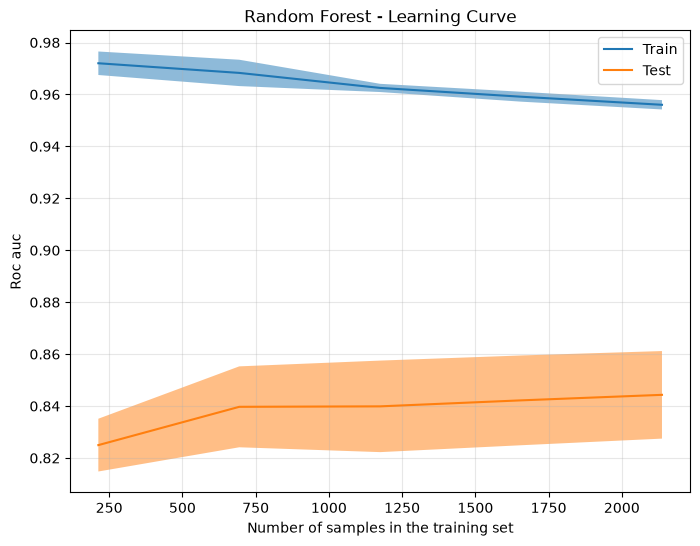

In [31]:
# RF Learning Curve Visualization

rf_best = grid_search_rf.best_estimator_

# Define a ShuffleSplit cross-validator for the learning curve
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Use LearningCurveDisplay to visualize
plt.figure(figsize=(8, 6))
LearningCurveDisplay.from_estimator(
    rf_best, 
    X_train, 
    y_train, 
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    ax=plt.gca()
)

plt.title('Random Forest - Learning Curve')
plt.grid(True, alpha=0.3)
plt.savefig(tuning_plots_dir / "03_RF_learning_curve.png", dpi=300)
plt.show()

In [32]:
# Evaluate the best model on the training and validation sets

evaluate_and_store_model_performance(rf_best, "Random Forest", X_train, y_train, X_val, y_val)

--- Model: Random Forest ---
Training set AUC:   0.952
Validation set AUC: 0.827



## 3. Tuning XGBoost

In [33]:
# Fast tuning with RandomizedSearchCV for XGBoost Classifier

xgb_clf = XGBClassifier(n_estimators=200, eval_metric='auc', random_state=1)

# Define the hyperparameter distribution for RandomizedSearchCV
param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],            #  Randomly select data to prevent overfitting
    'colsample_bytree': [0.8, 1.0]      #  Randomly select features to increase model diversity
}

# Set up the RandomizedSearchCV with the XGBoost model
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=20,             
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=1
)

random_search_xgb.fit(X_train, y_train, 
                      eval_set=[(X_train, y_train), (X_val, y_val)], 
                      verbose=20
)
print(f"Best parameter combination (Random search): {random_search_xgb.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[0]	validation_0-auc:0.77557	validation_1-auc:0.73584
[20]	validation_0-auc:0.86284	validation_1-auc:0.80172
[40]	validation_0-auc:0.87833	validation_1-auc:0.81900
[60]	validation_0-auc:0.88887	validation_1-auc:0.82417
[80]	validation_0-auc:0.89466	validation_1-auc:0.82756
[100]	validation_0-auc:0.89975	validation_1-auc:0.82944
[120]	validation_0-auc:0.90444	validation_1-auc:0.83061
[140]	validation_0-auc:0.90875	validation_1-auc:0.83258
[160]	validation_0-auc:0.91307	validation_1-auc:0.83372
[180]	validation_0-auc:0.91650	validation_1-auc:0.83562
[199]	validation_0-auc:0.91989	validation_1-auc:0.83559
Best parameter combination (Random search): {'subsample': 0.8, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [34]:
# Fine tuning with GridSearchCV for XGBoost Classifier

param_grid = {
    'learning_rate': [0.03, 0.05, 0.07],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [2, 3, 4],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.9, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='roc_auc',      
    cv=3,                   
    n_jobs=-1,              
    verbose=1              
)

grid_search_xgb.fit(X_train, y_train,
                    eval_set=[(X_train, y_train), (X_val, y_val)], 
                    verbose=20

)
print(f"Best parameter combination (Grid search): {grid_search_xgb.best_params_}")
xgb_best = grid_search_xgb.best_estimator_

Fitting 3 folds for each of 216 candidates, totalling 648 fits
[0]	validation_0-auc:0.77817	validation_1-auc:0.74507
[20]	validation_0-auc:0.85655	validation_1-auc:0.79199
[40]	validation_0-auc:0.86580	validation_1-auc:0.80911
[60]	validation_0-auc:0.87437	validation_1-auc:0.81669
[80]	validation_0-auc:0.88163	validation_1-auc:0.82036
[100]	validation_0-auc:0.88616	validation_1-auc:0.82317
[120]	validation_0-auc:0.89062	validation_1-auc:0.82549
[140]	validation_0-auc:0.89532	validation_1-auc:0.82804
[160]	validation_0-auc:0.89907	validation_1-auc:0.82849
[180]	validation_0-auc:0.90212	validation_1-auc:0.83047
[199]	validation_0-auc:0.90496	validation_1-auc:0.83146
Best parameter combination (Grid search): {'colsample_bytree': 0.9, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 2, 'subsample': 0.7}


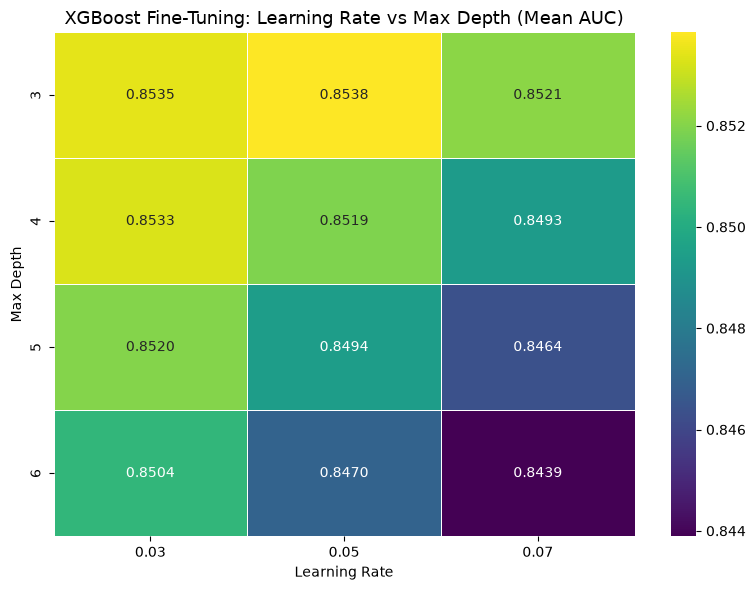

In [35]:
# Visualization of the GridSearchCV results for XGBoost hyperparameter tuning

# Convert the GridSearchCV results into a DataFrame for visualization
results_df = pd.DataFrame(grid_search_xgb.cv_results_)

# Extract the relevant columns for visualization
scores_df = results_df[[
    'param_learning_rate', 
    'param_max_depth', 
    'param_min_child_weight',
    'param_subsample',
    'param_colsample_bytree',
    'mean_test_score'
]].copy()

# Convert the columns to numeric
for col in scores_df.columns:
    scores_df[col] = pd.to_numeric(scores_df[col])

pivot_table = scores_df.pivot_table(
    index='param_max_depth', 
    columns='param_learning_rate', 
    values='mean_test_score', 
    aggfunc='mean'  
)

# Heatmap with seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_table, 
    annot=True, 
    fmt='.4f',         # AUC may be very close, so we use 4 decimal places
    cmap='viridis', 
    linewidths=0.5
)

plt.title('XGBoost Fine-Tuning: Learning Rate vs Max Depth (Mean AUC)', fontsize=13)
plt.xlabel('Learning Rate')
plt.ylabel('Max Depth')
plt.tight_layout()
plt.savefig(tuning_plots_dir / "04_XGB_tuning_heatmap.png", dpi=300)
plt.show()

In [36]:
# Evaluate the best model on the training and validation sets

evaluate_and_store_model_performance(xgb_best, "XGBoost", X_train, y_train, X_val, y_val)

--- Model: XGBoost ---
Training set AUC:   0.905
Validation set AUC: 0.831



## 4. Tuning CatBoost (With Optuna)

In [37]:
# Tuning CatBoost Classifier with Optuna

# Define the objective function for Optuna to optimize the hyperparameters of CatBoost
def objective(trial):
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 6),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 0.9),
        'cat_features': categorical_features,
        'eval_metric': 'AUC',
        'early_stopping_rounds': 50,
        'verbose': 0
    }
    
    model = CatBoostClassifier(**params)
    model.fit(df_train_eng, y_train, eval_set=(df_val_eng, y_val))
    
    preds = model.predict_proba(df_val_eng)[:, 1]
    auc = roc_auc_score(y_val, preds)
    return auc

# Run the optimization study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("Best trial AUC:", study.best_value)
print("Best params:", study.best_params)

# Train the final model using the best parameters found
cat_best = CatBoostClassifier(**study.best_params, 
                                iterations=1000, 
                                cat_features=categorical_features, 
                                early_stopping_rounds=50, 
                                random_seed=42,
                                use_best_model=True,
                                verbose=100)
cat_best.fit(df_train_eng, y_train, eval_set=(df_val_eng, y_val))

[I 2026-08-08 15:34:36,015] A new study created in memory with name: no-name-e1c58e57-7eb0-4418-aa0e-52be36dde39c
[I 2026-08-08 15:34:58,617] Trial 0 finished with value: 0.8369408587827857 and parameters: {'learning_rate': 0.019964533334623995, 'depth': 6, 'l2_leaf_reg': 6.320283191012674, 'subsample': 0.6642152123023356, 'colsample_bylevel': 0.6702185848753015}. Best is trial 0 with value: 0.8369408587827857.
[I 2026-08-08 15:35:11,182] Trial 1 finished with value: 0.8393808578140515 and parameters: {'learning_rate': 0.04298682058653981, 'depth': 5, 'l2_leaf_reg': 6.467358262705999, 'subsample': 0.7658053238131852, 'colsample_bylevel': 0.8107764895070848}. Best is trial 1 with value: 0.8393808578140515.
[I 2026-08-08 15:35:29,958] Trial 2 finished with value: 0.8346461698675256 and parameters: {'learning_rate': 0.012273600637693623, 'depth': 4, 'l2_leaf_reg': 9.960884252772923, 'subsample': 0.7094098835479518, 'colsample_bylevel': 0.677471157868644}. Best is trial 1 with value: 0.839

Best trial AUC: 0.841905621079654
Best params: {'learning_rate': 0.028009193264358828, 'depth': 6, 'l2_leaf_reg': 7.935127877885577, 'subsample': 0.6593801384563795, 'colsample_bylevel': 0.7300805428584014}
0:	learn: 0.6780327	test: 0.6796890	best: 0.6796890 (0)	total: 27.2ms	remaining: 27.2s
100:	learn: 0.3821491	test: 0.4578189	best: 0.4577764 (99)	total: 3.76s	remaining: 33.5s
200:	learn: 0.3468026	test: 0.4497769	best: 0.4496397 (197)	total: 7.4s	remaining: 29.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4488216301
bestIteration = 222

Shrink model to first 223 iterations.


CatBoostClassifier(cat_features=['home', 'marital', 'records', 'job', 'age_group'], colsample_bylevel=0.7300805428584014, depth=6, early_stopping_rounds=50, iterations=1000, l2_leaf_reg=7.935127877885577, learning_rate=0.028009193264358828, random_seed=42, subsample=0.6593801384563795, use_best_model=True, verbose=100)

In [38]:
# Visualize the Optuna optimization history and hyperparameter importances

# 1. Optimization History
fig1 = vis.plot_optimization_history(study)
fig1.update_layout(title='Optuna Optimization History for CatBoost Hyperparameter Tuning')
fig1.write_html(tuning_plots_dir / "05_CatBoost_Optuna_optimization_history.html")
fig1.show()

# 2. Hyperparameter Importances
fig2 = vis.plot_param_importances(study)
fig2.update_layout(title='Hyperparameter Importances for CatBoost Hyperparameter Tuning')
fig2.write_html(tuning_plots_dir / "06_CatBoost_Optuna_hyperparameter_importances.html")
fig2.show()

In [39]:
# Evaluate the best model on the training and validation sets

evaluate_and_store_model_performance(cat_best, "CatBoost", df_train_eng, y_train, df_val_eng, y_val)
# Use `df_train_eng` and `df_val_eng` for CatBoost since it can handle categorical features directly.

--- Model: CatBoost ---
Training set AUC:   0.911
Validation set AUC: 0.836



# Simple Average and Weighted Optimised Ensemble

In [40]:
# Simple Average Ensemble Method

# 1. Get predictions from the best models for the validation and training sets
preds_val_list = [
    rf_best.predict_proba(X_val)[:, 1],
    xgb_best.predict_proba(X_val)[:, 1],
    cat_best.predict_proba(df_val_eng)[:, 1] # CatBoost 專用
]

preds_train_list = [
    rf_best.predict_proba(X_train)[:, 1],
    xgb_best.predict_proba(X_train)[:, 1],
    cat_best.predict_proba(df_train_eng)[:, 1] # CatBoost 專用
]

# 2. Simple Average
y_pred_val_simple_avg = np.mean(preds_val_list, axis=0)
y_pred_train_simple_avg = np.mean(preds_train_list, axis=0)

# 3. Calculate AUC for the simple average ensemble predictions
auc_val_sa = roc_auc_score(y_val, y_pred_val_simple_avg)
auc_train_sa = roc_auc_score(y_train, y_pred_train_simple_avg)

print(f"Simple Average - Train AUC: {auc_train_sa:.4f}")
print(f"Simple Average - Validation AUC: {auc_val_sa:.4f}")

#
model_results['Simple Average'] = {
    'model': 'Ensemble (Simple Average)',
    'train_pred': y_pred_train_simple_avg,
    'train_auc': auc_train_sa,
    'val_pred': y_pred_val_simple_avg,
    'val_auc': auc_val_sa
}

Simple Average - Train AUC: 0.9258
Simple Average - Validation AUC: 0.8345


In [41]:
# Weighted Optimized Ensemble Method

# 1. define the objective function for optimizing the weights of the ensemble models
def objective_weights(weights):
    # Normalize the weights to ensure they sum to 1
    weights = np.array(weights)
    weights = weights / np.sum(weights)
    
    # Calculate the weighted average prediction
    weighted_pred = sum(w * p for w, p in zip(weights, preds_val_list))
    
    # Because minimize finds the minimum value, return the negative AUC
    return -roc_auc_score(y_val, weighted_pred)


# 2. Initial setup 
initial_weights = [1/len(preds_val_list)] * len(preds_val_list)     # Set initial weights (uniform distribution)
bounds = [(0, 1)] * len(preds_val_list)                             # Set weight bounds (each weight must be between 0 and 1)
constraint = {'type': 'eq', 'fun': lambda w: sum(w) - 1}            # Set constraint: the sum of weights must equal 1


# 3. Optimize the weights using SLSQP (Sequential Least Squares Programming) method
result = minimize(objective_weights, initial_weights, method='SLSQP', bounds=bounds, constraints=constraint)

best_weights = result.x
best_weights = best_weights / np.sum(best_weights) # Make sure the weights sum to 1

print("Optimized Weights for [RF, XGB, CatBoost]:", np.round(best_weights, 4))


# 4. Calculate the weighted predictions and AUC scores for both training and validation sets
y_pred_val_weighted = sum(w * p for w, p in zip(best_weights, preds_val_list))
y_pred_train_weighted = sum(w * p for w, p in zip(best_weights, preds_train_list))

auc_val_wo = roc_auc_score(y_val, y_pred_val_weighted)
auc_train_wo = roc_auc_score(y_train, y_pred_train_weighted)

print(f"Weighted Optimised - Train AUC: {auc_train_wo:.4f}")
print(f"Weighted Optimised - Validation AUC: {auc_val_wo:.4f}")

# 5. Store the results in the model_results dictionary
model_results['Weighted Optimised'] = {
    'model': f'Ensemble (Weighted: {np.round(best_weights, 2)})',
    'train_pred': y_pred_train_weighted,
    'train_auc': auc_train_wo,
    'val_pred': y_pred_val_weighted,
    'val_auc': auc_val_wo
}

Optimized Weights for [RF, XGB, CatBoost]: [0.3333 0.3333 0.3333]
Weighted Optimised - Train AUC: 0.9258
Weighted Optimised - Validation AUC: 0.8345


# Comparing Tuned Models

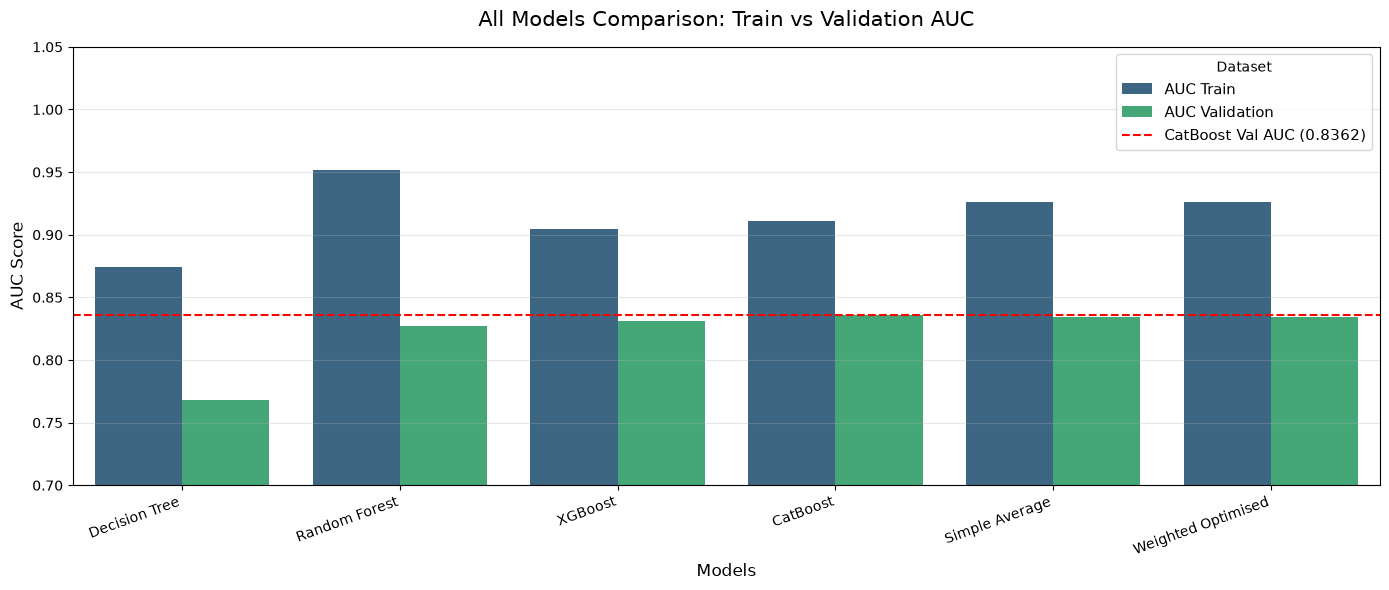

In [42]:
# Visualization of All Models AUC Scores

# 1. Extract AUC scores for all models from model_results
performance_data = []

for model_name, res in model_results.items():
    performance_data.append({
        'Model': model_name,
        'AUC Train': res['train_auc'],
        'AUC Validation': res['val_auc']
    })

comparison_df = pd.DataFrame(performance_data)
model_order = ['Decision Tree', 'Random Forest', 'XGBoost', 'CatBoost', 'Simple Average', 'Weighted Optimised']
comparison_df['Model'] = pd.Categorical(comparison_df['Model'], categories=model_order, ordered=True)
comparison_df = comparison_df.sort_values('Model').reset_index(drop=True)

# 2. Convert the DataFrame to long format for easier plotting with Seaborn
df_melted = comparison_df.melt(
    id_vars='Model', 
    value_vars=['AUC Train', 'AUC Validation'], 
    var_name='Dataset', 
    value_name='AUC Score'
)

# 3. Plotting with Seaborn
fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    x='Model', 
    y='AUC Score', 
    hue='Dataset', 
    data=df_melted, 
    palette='viridis',
    ax=ax
)

# 4. Add a red horizontal line to indicate the CatBoost validation AUC as a benchmark
catboost_val_auc = comparison_df.loc[comparison_df['Model'] == 'CatBoost', 'AUC Validation'].values[0]

plt.axhline(
    y=catboost_val_auc, 
    color='red', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'CatBoost Val AUC ({catboost_val_auc:.4f})'
)

plt.title('All Models Comparison: Train vs Validation AUC', fontsize=15, pad=15)
plt.xlabel('Models', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.ylim(0.7, 1.05)
plt.xticks(rotation=20, ha='right')
plt.grid(True, axis='y', alpha=0.3)
plt.legend(title='Dataset', loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig(evaluation_plots_dir / '02_final_models_comparison.png', dpi=300)
plt.show()

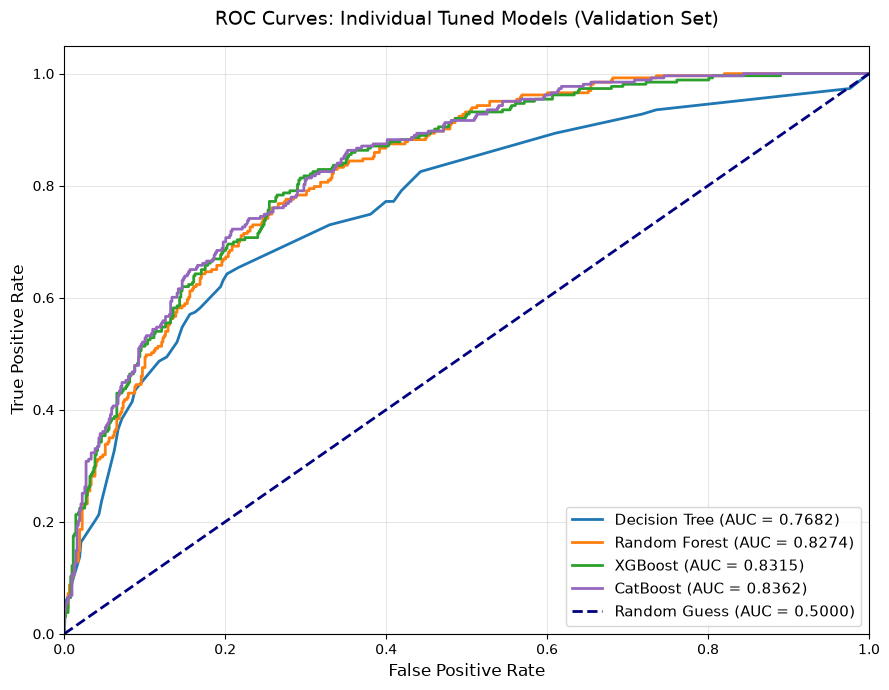

In [43]:
# ROC Curves for Individual Tuned Models

plt.figure(figsize=(9, 7))

# Define the models and their corresponding colors for plotting
models_group_1 = ['Decision Tree', 'Random Forest', 'XGBoost', 'CatBoost']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']

for model_name, color in zip(models_group_1, colors):
    if model_name in model_results:
        y_pred = model_results[model_name]['val_pred']
        auc_val = model_results[model_name]['val_auc']
        
        # Calculate FPR, TPR
        fpr, tpr, _ = roc_curve(y_val, y_pred)
        
        plt.plot(fpr, tpr, color=color, lw=2, 
                 label=f'{model_name} (AUC = {auc_val:.4f})')

# Plot the diagonal line for random guessing (AUC = 0.5)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves: Individual Tuned Models (Validation Set)', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(evaluation_plots_dir / '03_ROC_curves_individual_models.png', dpi=300)
plt.show()

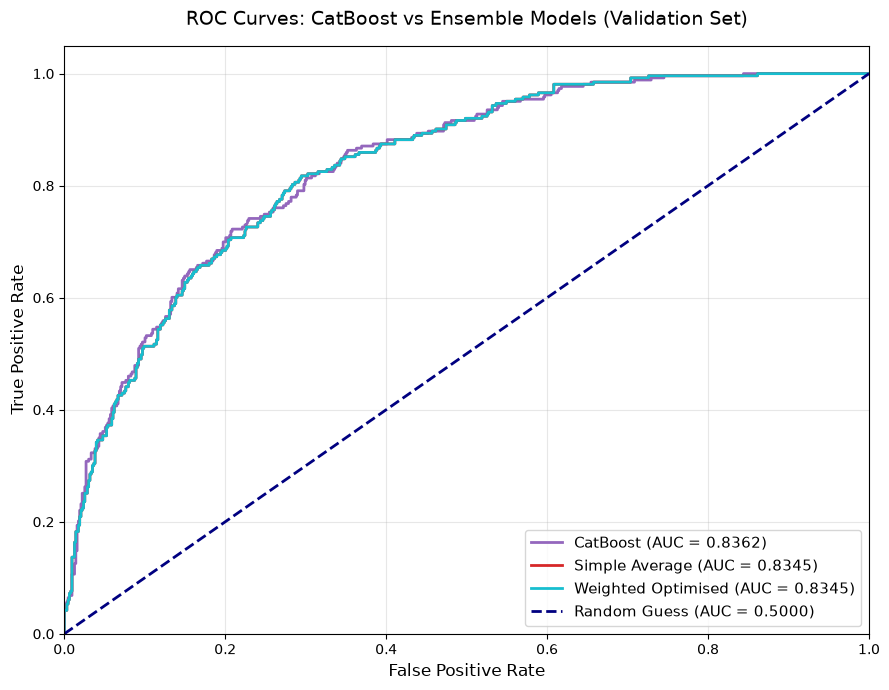

In [44]:
# ROC Curves for CatBoost vs Ensemble Models

plt.figure(figsize=(9, 7))

# Define the ensemble models and their corresponding colors for plotting
models_group_2 = ['CatBoost', 'Simple Average', 'Weighted Optimised']
colors = ['tab:purple', 'tab:red', 'tab:cyan']

for model_name, color in zip(models_group_2, colors):
    if model_name in model_results:
        y_pred = model_results[model_name]['val_pred']
        auc_val = model_results[model_name]['val_auc']
        
        fpr, tpr, _ = roc_curve(y_val, y_pred)
        
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{model_name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves: CatBoost vs Ensemble Models (Validation Set)', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(evaluation_plots_dir / '04_ROC_curves_catboost_vs_ensemble.png', dpi=300)
plt.show()

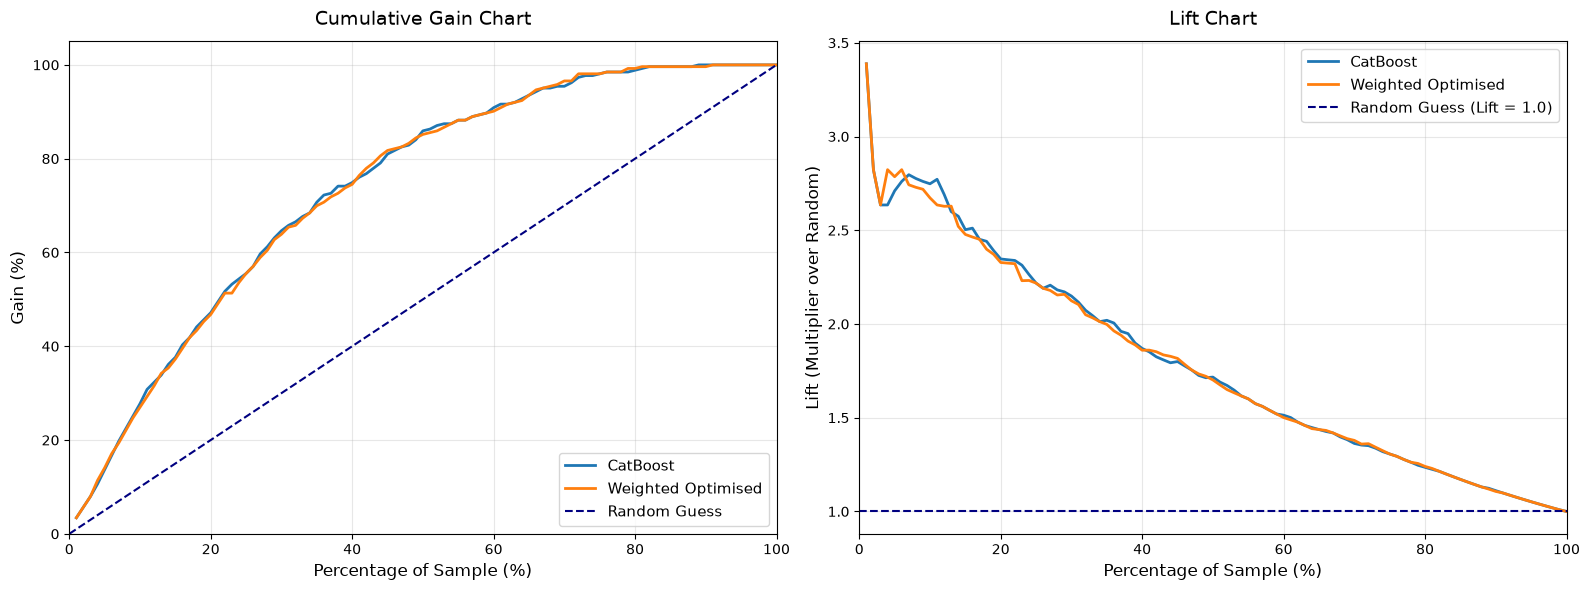

In [45]:
# Lift and Gain Charts for CatBoost vs Ensemble Models

def plot_gain_and_lift(y_true, model_results, models_to_show):
    y_true = np.array(y_true)                       # The true labels for the validation set
    n_samples = len(y_true)                         # Total number of samples in the validation set
    total_positives = np.sum(y_true)                # Total number of positive samples in the validation set
    baseline_rate = total_positives / n_samples     # Baseline positive rate (for random guessing)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    percentiles = np.linspace(1, 100, 100)
    
    for name in models_to_show:
        if name in model_results:
            y_score = model_results[name]['val_pred']
            
            # Sort the predicted scores and corresponding true labels in descending order
            sorted_indices = np.argsort(y_score)[::-1]
            sorted_y_true = y_true[sorted_indices]
            
            gain_values = []
            lift_values = []
            
            for p in percentiles:
                n_p = int(np.ceil(n_samples * (p / 100.0)))
                # True positives in the top p% of the predicted scores
                cum_pos = np.sum(sorted_y_true[:n_p])
                
                # 1. Gain %
                gain = (cum_pos / total_positives) * 100
                gain_values.append(gain)
                
                # 2. Lift
                model_rate = cum_pos / n_p
                lift = model_rate / baseline_rate
                lift_values.append(lift)
            
            # --- Left：Cumulative Gain Chart ---
            axes[0].plot(percentiles, gain_values, label=name, lw=2)
            
            # --- Right：Lift Chart ---
            axes[1].plot(percentiles, lift_values, label=name, lw=2)
            
    # --- Gain ---
    axes[0].plot([0, 100], [0, 100], color='navy', linestyle='--', label='Random Guess')
    axes[0].set_title('Cumulative Gain Chart', fontsize=14, pad=12)
    axes[0].set_xlabel('Percentage of Sample (%)', fontsize=12)
    axes[0].set_ylabel('Gain (%)', fontsize=12)
    axes[0].set_xlim([0, 100])
    axes[0].set_ylim([0, 105])
    axes[0].legend(loc="lower right", fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # --- Lift ---
    axes[1].axhline(y=1.0, color='navy', linestyle='--', label='Random Guess (Lift = 1.0)')
    axes[1].set_title('Lift Chart', fontsize=14, pad=12)
    axes[1].set_xlabel('Percentage of Sample (%)', fontsize=12)
    axes[1].set_ylabel('Lift (Multiplier over Random)', fontsize=12)
    axes[1].set_xlim([0, 100])
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc="upper right", fontsize=11)
    
    plt.tight_layout()
    plt.savefig(evaluation_plots_dir / '05_gain_and_lift_charts.png', dpi=300)
    plt.show()

plot_gain_and_lift(y_val, model_results, ['CatBoost', 'Weighted Optimised'])

# Saving Final Models and Results

In [48]:
# Save the final model results to a CSV file for future reference
final_results_df = pd.DataFrame([
    {
        'Model': name,
        'Train AUC': res['train_auc'],
        'Validation AUC': res['val_auc']
    } for name, res in model_results.items()
])
final_results_df.to_csv(models_dir / 'final_model_performance.csv', index=False)

In [46]:
# Save model to disk using joblib

joblib.dump(dt_best, models_dir / 'dt_best_model.joblib')
joblib.dump(rf_best, models_dir / 'rf_best_model.joblib')
joblib.dump(xgb_best, models_dir / 'xgb_best_model.joblib')
joblib.dump(cat_best, models_dir / 'cat_best_model.joblib')

# Ensemble weights for the optimized ensemble model
best_weights = [0.3333, 0.3333, 0.3333] 

# Metadata
ensemble_metadata = {
    'models_used': ['Random Forest', 'XGBoost', 'CatBoost'],
    'weights': best_weights
}

# Save the ensemble weights to a JSON file for future reference
with open(models_dir / 'ensemble_weights.json', 'w') as f:
    json.dump(ensemble_metadata, f, indent=4)

print("Ensemble weights saved successfully!")



# # 1. Load individual models
# rf_loaded = joblib.load(models_dir / 'rf_best_model.joblib')
# xgb_loaded = joblib.load(models_dir / 'xgb_best_model.joblib')
# cat_loaded = joblib.load(models_dir / 'cat_best_model.joblib')

# # 2. Load the ensemble weights from the JSON file
# with open(models_dir / 'ensemble_weights.json', 'r') as f:
#     metadata = json.load(f)
# w = metadata['weights']

# # 3. Make predictions
# final_test_preds = (
#     w[0] * rf_loaded.predict_proba(X_test)[:, 1] +
#     w[1] * xgb_loaded.predict_proba(X_test)[:, 1] +
#     w[2] * cat_loaded.predict_proba(df_test_eng)[:, 1]  # CatBoost use `df_test_eng`
# )

Ensemble weights saved successfully!


# Feature Importance

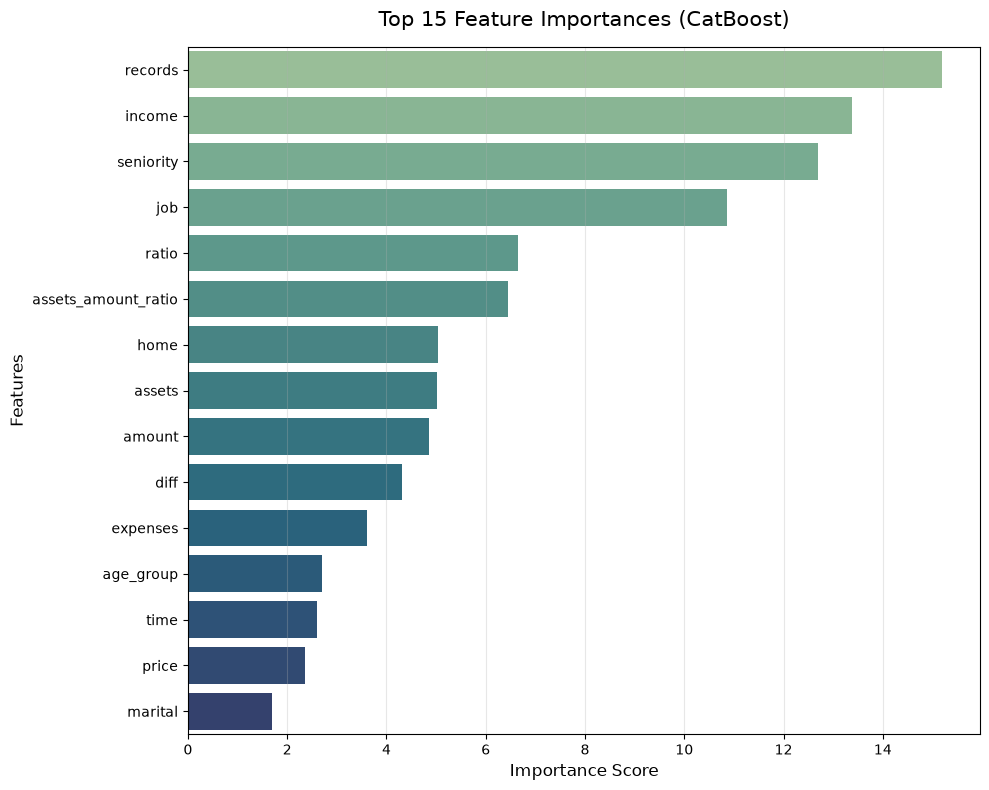

In [49]:
# Feature importance from CatBoost

# 1. Extract CatBoost's Feature Importance values
feature_importances = cat_best.get_feature_importance()
feature_names = df_train_eng.columns

# 2. Create DataFrame and sort (from high to low)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Top 15 Most Important Features as a Horizontal Bar Chart
plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance', 
    y='Feature', 
    hue='Feature',
    data=importance_df.head(15),
    palette='crest',
    legend=False
)

plt.title('Top 15 Feature Importances (CatBoost)', fontsize=15, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(features_plots_dir / '01_catboost_feature_importance.png', dpi=300)
plt.show()